<a href="https://colab.research.google.com/github/hilya-23/CNN_Melon/blob/main/CNN_MELON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteksi Kekurangan Makronutrien Melon Menggunakan ResNet50

## Pendahuluan
Notebook ini mendemonstrasikan implementasi model _deep learning_ (ResNet50) untuk mendeteksi kekurangan makronutrien pada tanaman melon. Proyek ini mengeksplorasi tiga skenario berbeda: Transfer Learning dasar, Transfer Learning dengan Augmentasi Data, dan Transfer Learning dengan Augmentasi Data dan Fine-tuning.

## Dataset
Dataset yang digunakan terdiri dari gambar-gambar daun melon yang dikategorikan berdasarkan kekurangan makronutrien dan kondisi sehat. Kelas-kelas yang ada meliputi:
- `calcium` (kekurangan kalsium)
- `health` (sehat)
- `nitrogen` (kekurangan nitrogen)
- `potasium` (kekurangan kalium)

Jumlah total gambar dalam dataset adalah **200 gambar**, dengan **50 gambar** untuk setiap kelas.

## Pra-pemrosesan Data
1.  **Split Data:** Dataset dibagi menjadi subset pelatihan (_training_), validasi (_validation_), dan pengujian (_testing_) dengan rasio berikut:
    -   _Training_: 80% (160 gambar)
    -   _Validation_: 10% (20 gambar)
    -   _Testing_: 10% (20 gambar)
2.  **Transformasi Gambar:** Gambar diubah ukurannya menjadi 224x224 piksel dan dinormalisasi menggunakan _mean_ dan _standard deviation_ ImageNet.
3.  **Augmentasi Data (untuk Skenario 2 & 3):** Untuk data pelatihan, augmentasi diterapkan termasuk `RandomResizedCrop`, `RandomHorizontalFlip`, `RandomRotation`, dan `ColorJitter` untuk meningkatkan variasi data dan membantu mencegah _overfitting_.

## Model dan Skenario Eksperimen
Semua skenario menggunakan arsitektur model ResNet50 yang telah dilatih sebelumnya (_pre-trained_) pada dataset ImageNet. Lapisan klasifikasi terakhir (Fully Connected layer) disesuaikan untuk empat kelas keluaran spesifik pada dataset melon.

### Skenario 1: Transfer Learning (Dasar)
-   **Strategi:** Membekukan semua lapisan ResNet50 kecuali lapisan Fully Connected (FC) terakhir, yang dilatih dari awal.
-   **Augmentasi:** Tidak ada augmentasi data yang digunakan.
-   **Optimizer:** Adam dengan _learning rate_ 0.001.
-   **Epochs:** 10
-   **Hasil Evaluasi pada Data Uji:**
    -   Accuracy  : 1.0000
    -   Precision : 1.0000
    -   Recall    : 1.0000
    -   F1-Score  : 1.0000

### Skenario 2: Transfer Learning + Augmentasi Data
-   **Strategi:** Sama seperti Skenario 1 (membekukan semua lapisan kecuali FC terakhir).
-   **Augmentasi:** Augmentasi data diterapkan pada data pelatihan.
-   **Optimizer:** Adam dengan _learning rate_ 0.001.
-   **Epochs:** 10
-   **Hasil Evaluasi pada Data Uji:**
    -   Accuracy  : 1.0000
    -   Precision : 1.0000
    -   Recall    : 1.0000
    -   F1-Score  : 1.0000

### Skenario 3: Transfer Learning + Augmentasi Data + Fine-tuning
-   **Strategi:** Membekukan sebagian besar lapisan ResNet50, tetapi **melepas pembekuan (_unfreeze_) lapisan konvolusional terakhir (layer4) dan lapisan FC terakhir**. Kedua lapisan ini dilatih kembali (_fine-tuned_).
-   **Augmentasi:** Augmentasi data diterapkan pada data pelatihan.
-   **Optimizer:** Adam dengan _learning rate_ 0.001 untuk lapisan FC dan 0.0001 (lebih rendah) untuk lapisan konvolusional (layer4).
-   **Epochs:** 10
-   **Hasil Evaluasi pada Data Uji:**
    -   Accuracy  : 1.0000
    -   Precision : 1.0000
    -   Recall    : 1.0000
    -   F1-Score  : 1.0000

## Kesimpulan
Semua skenario menunjukkan performa yang sangat baik pada dataset pengujian, mencapai akurasi 100%. Hal ini mungkin disebabkan oleh ukuran dataset yang relatif kecil dan perbedaan visual yang jelas antar kelas. Implementasi augmentasi data dan _fine-tuning_ pada Skenario 2 dan 3 adalah praktik terbaik untuk generalisasi model yang lebih baik pada dataset yang lebih besar atau lebih kompleks di masa mendatang.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATASET_DIR = "/content/drive/MyDrive/dataset_melon/Melon macronutrient deficeincy datasets"

print("Lokasi dataset:")
print(DATASET_DIR)

Lokasi dataset:
/content/drive/MyDrive/dataset_melon/Melon macronutrient deficeincy datasets


In [6]:
import os

classes = os.listdir(DATASET_DIR)

print("Kelas yang ditemukan:")
for class_name in classes:
    print("-", class_name)

Kelas yang ditemukan:
- nitrogen
- health
- potasium
- calcium


In [8]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

total_images = 0

for class_name in sorted(classes):

    class_path = os.path.join(DATASET_DIR, class_name)

    image_count = sum(
        1
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    )

    print(f"{class_name}: {image_count} gambar")

    total_images += image_count

print("--------------------------")
print("Total gambar:", total_images)

calcium: 50 gambar
health: 50 gambar
nitrogen: 50 gambar
potasium: 50 gambar
--------------------------
Total gambar: 200


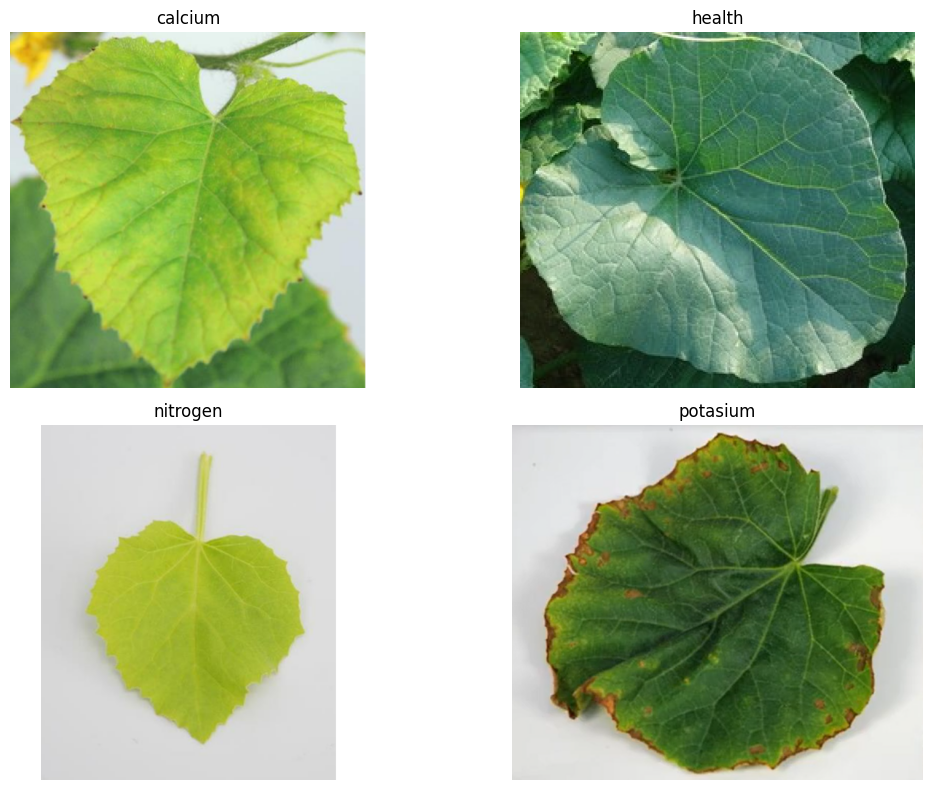

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))

class_names = sorted(classes)

for i, class_name in enumerate(class_names):

    class_path = os.path.join(DATASET_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    image_path = os.path.join(class_path, image_files[0])

    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import random
import shutil

random.seed(42)

SPLIT_DIR = "/content/melon_cnn_split"

# Hapus folder split lama jika ada
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# Buat folder train, val, test
for split in ["train", "val", "test"]:
    for class_name in class_names:
        os.makedirs(
            os.path.join(SPLIT_DIR, split, class_name),
            exist_ok=True
        )

# Membagi setiap kelas
for class_name in class_names:

    class_path = os.path.join(DATASET_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    random.shuffle(image_files)

    total = len(image_files)

    train_end = int(0.8 * total)
    val_end = train_end + int(0.1 * total)

    train_files = image_files[:train_end]
    val_files = image_files[train_end:val_end]
    test_files = image_files[val_end:]

    # Copy train
    for file_name in train_files:
        shutil.copy2(
            os.path.join(class_path, file_name),
            os.path.join(SPLIT_DIR, "train", class_name, file_name)
        )

    # Copy validation
    for file_name in val_files:
        shutil.copy2(
            os.path.join(class_path, file_name),
            os.path.join(SPLIT_DIR, "val", class_name, file_name)
        )

    # Copy test
    for file_name in test_files:
        shutil.copy2(
            os.path.join(class_path, file_name),
            os.path.join(SPLIT_DIR, "test", class_name, file_name)
        )

print("Dataset berhasil dibagi.")
print("Lokasi:", SPLIT_DIR)

Dataset berhasil dibagi.
Lokasi: /content/melon_cnn_split


In [11]:
for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")
    print("-" * 30)

    total = 0

    for class_name in class_names:

        class_path = os.path.join(
            SPLIT_DIR,
            split,
            class_name
        )

        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(image_extensions)
        ])

        print(f"{class_name}: {count}")
        total += count

    print("Total:", total)


TRAIN
------------------------------
calcium: 40
health: 40
nitrogen: 40
potasium: 40
Total: 160

VAL
------------------------------
calcium: 5
health: 5
nitrogen: 5
potasium: 5
Total: 20

TEST
------------------------------
calcium: 5
health: 5
nitrogen: 5
potasium: 5
Total: 20


In [12]:
import torch
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Preprocessing berhasil dibuat.")
print("Ukuran gambar:", IMG_SIZE, "x", IMG_SIZE)

Preprocessing berhasil dibuat.
Ukuran gambar: 224 x 224


In [13]:
from torchvision import datasets

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

print("Jumlah data train :", len(train_dataset))
print("Jumlah data val   :", len(val_dataset))
print("Jumlah data test  :", len(test_dataset))

print("\nNama kelas:")
print(train_dataset.classes)

print("\nMapping kelas:")
print(train_dataset.class_to_idx)

Jumlah data train : 160
Jumlah data val   : 20
Jumlah data test  : 20

Nama kelas:
['calcium', 'health', 'nitrogen', 'potasium']

Mapping kelas:
{'calcium': 0, 'health': 1, 'nitrogen': 2, 'potasium': 3}


In [14]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoader berhasil dibuat.")
print("Batch size:", BATCH_SIZE)

DataLoader berhasil dibuat.
Batch size: 16


In [15]:
images, labels = next(iter(train_loader))

print("Shape gambar :", images.shape)
print("Shape label  :", labels.shape)
print("Label        :", labels)
print("Nilai minimum:", images.min().item())
print("Nilai maksimum:", images.max().item())

Shape gambar : torch.Size([16, 3, 224, 224])
Shape label  : torch.Size([16])
Label        : tensor([0, 1, 2, 1, 0, 2, 3, 0, 2, 3, 3, 2, 1, 3, 1, 2])
Nilai minimum: -2.0836544036865234
Nilai maksimum: 2.640000104904175


**SKENARIO 1**

In [16]:
import torch
import torch.nn as nn
from torchvision import models

# Menentukan device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device yang digunakan:", device)

# Mengambil ResNet50 pretrained
weights = models.ResNet50_Weights.DEFAULT

model = models.resnet50(weights=weights)

# Membekukan seluruh layer ResNet50
for param in model.parameters():
    param.requires_grad = False

# Menyesuaikan layer terakhir dengan jumlah kelas dataset melon
num_classes = len(train_dataset.classes)
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    num_classes
)

# Memindahkan model ke device
model = model.to(device)

print("Jumlah kelas:", num_classes)
print("Kelas:", train_dataset.classes)
print("Model ResNet50 berhasil dibuat.")

Device yang digunakan: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


Jumlah kelas: 4
Kelas: ['calcium', 'health', 'nitrogen', 'potasium']
Model ResNet50 berhasil dibuat.


In [17]:
for param in model.parameters():
    param.requires_grad = False

In [18]:
model.fc = nn.Linear(
    num_features,
    num_classes
)

In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam")
print("Learning rate : 0.001")

Loss function : CrossEntropyLoss
Optimizer     : Adam
Learning rate : 0.001


In [20]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10
):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # ==========================
        # TRAINING
        # ==========================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = correct / total

        # ==========================
        # VALIDATION
        # ==========================
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (
                    predicted == labels
                ).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = val_correct / val_total

        # Simpan hasil
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

In [21]:
EPOCHS = 10

history_s1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS
)

Epoch [1/10] Train Loss: 1.0980 | Train Acc: 0.8125 | Val Loss: 1.0597 | Val Acc: 0.9500
Epoch [2/10] Train Loss: 0.6342 | Train Acc: 0.9938 | Val Loss: 0.6840 | Val Acc: 1.0000
Epoch [3/10] Train Loss: 0.3869 | Train Acc: 0.9875 | Val Loss: 0.4688 | Val Acc: 1.0000
Epoch [4/10] Train Loss: 0.2675 | Train Acc: 0.9875 | Val Loss: 0.3044 | Val Acc: 1.0000
Epoch [5/10] Train Loss: 0.2043 | Train Acc: 0.9875 | Val Loss: 0.2187 | Val Acc: 1.0000
Epoch [6/10] Train Loss: 0.1545 | Train Acc: 0.9938 | Val Loss: 0.1826 | Val Acc: 1.0000
Epoch [7/10] Train Loss: 0.1442 | Train Acc: 0.9938 | Val Loss: 0.1565 | Val Acc: 1.0000
Epoch [8/10] Train Loss: 0.1245 | Train Acc: 1.0000 | Val Loss: 0.1354 | Val Acc: 1.0000
Epoch [9/10] Train Loss: 0.0887 | Train Acc: 1.0000 | Val Loss: 0.1235 | Val Acc: 1.0000
Epoch [10/10] Train Loss: 0.0778 | Train Acc: 0.9938 | Val Loss: 0.1138 | Val Acc: 1.0000


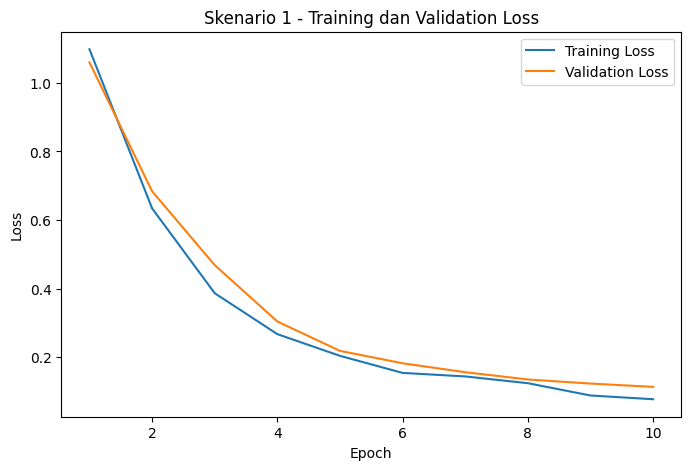

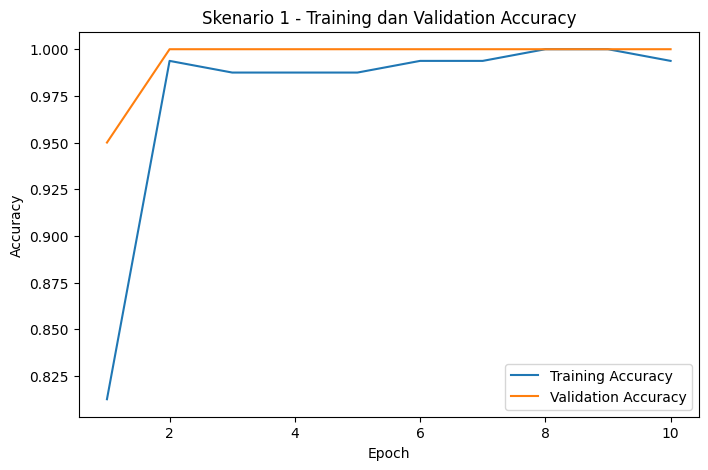

In [22]:
import matplotlib.pyplot as plt

train_losses, val_losses, train_acc, val_acc = history_s1

epochs_range = range(1, EPOCHS + 1)

# Plot Loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Skenario 1 - Training dan Validation Loss")
plt.legend()
plt.show()


# Plot Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_acc,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_acc,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Skenario 1 - Training dan Validation Accuracy")
plt.legend()
plt.show()

In [23]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

print("Testing selesai.")
print("Jumlah data test:", len(all_labels))

Testing selesai.
Jumlah data test: 20


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print("HASIL EVALUASI SKENARIO 1")
print("==========================")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

HASIL EVALUASI SKENARIO 1
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


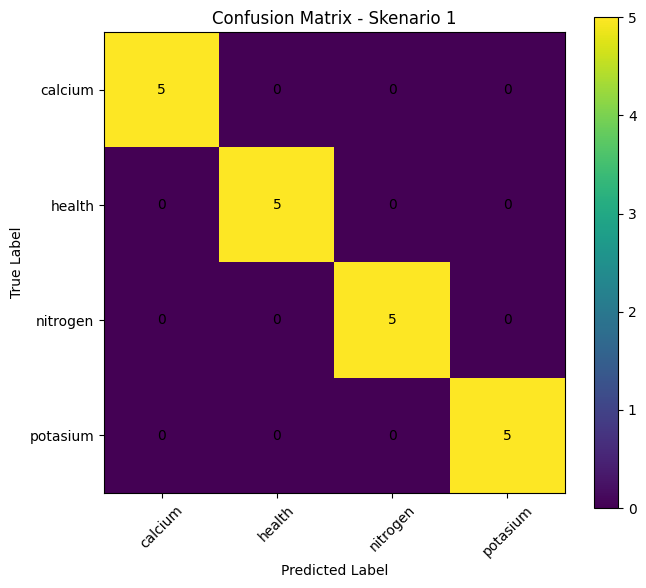

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - Skenario 1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(train_dataset.classes)),
    train_dataset.classes,
    rotation=45
)

plt.yticks(
    range(len(train_dataset.classes)),
    train_dataset.classes
)

# Menampilkan angka pada setiap kotak
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes,
    zero_division=0
)

print("CLASSIFICATION REPORT - SKENARIO 1")
print("===================================")
print(report)

CLASSIFICATION REPORT - SKENARIO 1
              precision    recall  f1-score   support

     calcium       1.00      1.00      1.00         5
      health       1.00      1.00      1.00         5
    nitrogen       1.00      1.00      1.00         5
    potasium       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



**SKENARIO 2**

In [27]:
from torchvision import transforms

IMG_SIZE = 224

train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        degrees=15
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation dan test tetap tanpa augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Data augmentation berhasil dibuat.")
print("Augmentation hanya diterapkan pada data training.")

Data augmentation berhasil dibuat.
Augmentation hanya diterapkan pada data training.


In [28]:
train_dataset_s2 = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform_aug
)

val_dataset_s2 = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset_s2 = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

print("Dataset Skenario 2 berhasil dibuat.")

print("\nJumlah data:")
print("Train      :", len(train_dataset_s2))
print("Validation :", len(val_dataset_s2))
print("Test       :", len(test_dataset_s2))

print("\nNama kelas:")
print(train_dataset_s2.classes)

Dataset Skenario 2 berhasil dibuat.

Jumlah data:
Train      : 160
Validation : 20
Test       : 20

Nama kelas:
['calcium', 'health', 'nitrogen', 'potasium']


In [29]:
BATCH_SIZE = 16

train_loader_s2 = DataLoader(
    train_dataset_s2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader_s2 = DataLoader(
    val_dataset_s2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader_s2 = DataLoader(
    test_dataset_s2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoader Skenario 2 berhasil dibuat.")
print("Batch size:", BATCH_SIZE)

DataLoader Skenario 2 berhasil dibuat.
Batch size: 16


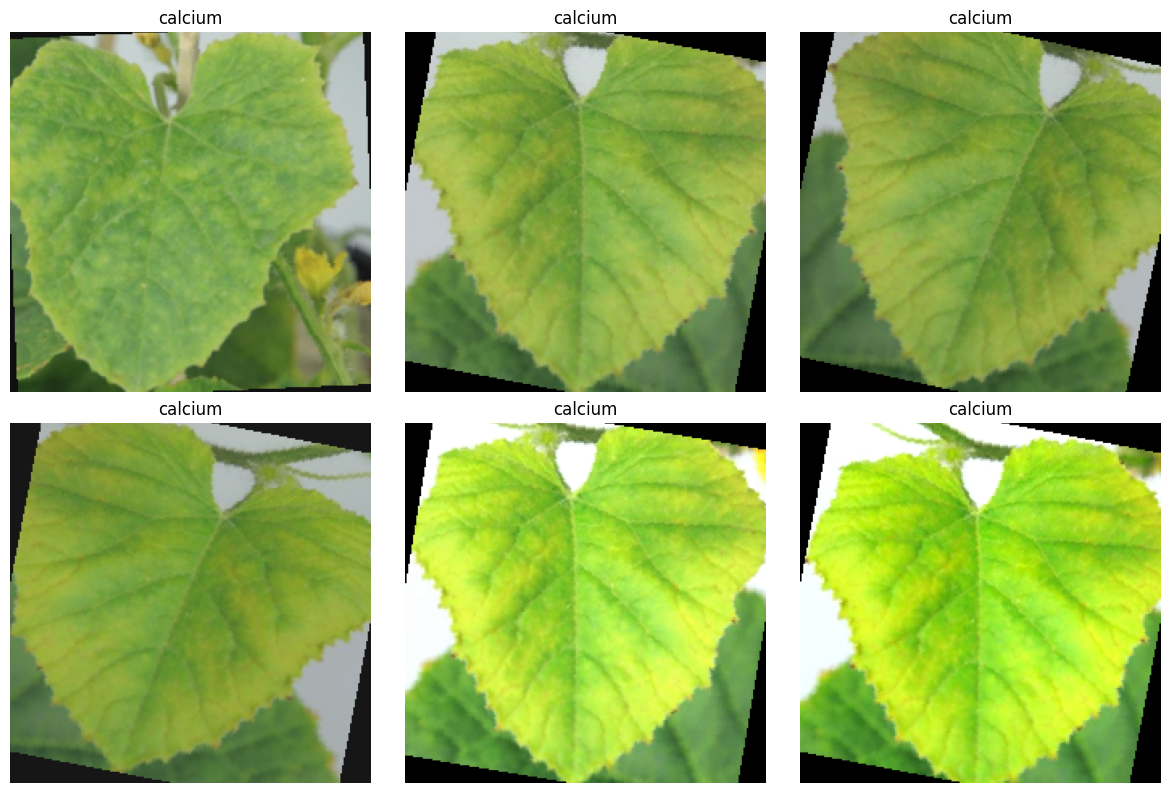

In [30]:
import torch
import matplotlib.pyplot as plt

# Ambil 6 gambar berbeda dari dataset training
plt.figure(figsize=(12, 8))

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

for i in range(6):

    image, label = train_dataset_s2[i]

    # Mengembalikan normalisasi agar gambar bisa ditampilkan
    image_display = image * std + mean
    image_display = torch.clamp(
        image_display,
        0,
        1
    )

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        image_display.permute(1, 2, 0)
    )

    plt.title(
        f"{train_dataset_s2.classes[label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
weights = models.ResNet50_Weights.DEFAULT

model_s2 = models.resnet50(
    weights=weights
)

# Membekukan seluruh layer ResNet50
for param in model_s2.parameters():
    param.requires_grad = False

# Mengganti classifier terakhir
num_classes = len(train_dataset_s2.classes)
num_features = model_s2.fc.in_features

model_s2.fc = nn.Linear(
    num_features,
    num_classes
)

# Pindahkan model ke device
model_s2 = model_s2.to(device)

print("Model Skenario 2 berhasil dibuat.")
print("Jumlah kelas:", num_classes)
print("Kelas:", train_dataset_s2.classes)

Model Skenario 2 berhasil dibuat.
Jumlah kelas: 4
Kelas: ['calcium', 'health', 'nitrogen', 'potasium']


In [32]:
criterion_s2 = nn.CrossEntropyLoss()

optimizer_s2 = torch.optim.Adam(
    model_s2.fc.parameters(),
    lr=0.001
)

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam")
print("Learning rate : 0.001")

Loss function : CrossEntropyLoss
Optimizer     : Adam
Learning rate : 0.001


In [33]:
EPOCHS_S2 = 10

history_s2 = train_model(
    model=model_s2,
    train_loader=train_loader_s2,
    val_loader=val_loader_s2,
    criterion=criterion_s2,
    optimizer=optimizer_s2,
    epochs=EPOCHS_S2
)

Epoch [1/10] Train Loss: 1.2392 | Train Acc: 0.5500 | Val Loss: 1.1775 | Val Acc: 0.5500
Epoch [2/10] Train Loss: 0.8750 | Train Acc: 0.9375 | Val Loss: 0.8451 | Val Acc: 1.0000
Epoch [3/10] Train Loss: 0.6319 | Train Acc: 0.9750 | Val Loss: 0.6384 | Val Acc: 1.0000
Epoch [4/10] Train Loss: 0.4698 | Train Acc: 0.9812 | Val Loss: 0.5185 | Val Acc: 1.0000
Epoch [5/10] Train Loss: 0.3480 | Train Acc: 0.9812 | Val Loss: 0.4145 | Val Acc: 1.0000
Epoch [6/10] Train Loss: 0.3312 | Train Acc: 0.9812 | Val Loss: 0.3630 | Val Acc: 1.0000
Epoch [7/10] Train Loss: 0.2473 | Train Acc: 0.9812 | Val Loss: 0.2974 | Val Acc: 1.0000
Epoch [8/10] Train Loss: 0.2394 | Train Acc: 0.9812 | Val Loss: 0.2457 | Val Acc: 1.0000
Epoch [9/10] Train Loss: 0.1818 | Train Acc: 0.9875 | Val Loss: 0.2087 | Val Acc: 1.0000
Epoch [10/10] Train Loss: 0.1574 | Train Acc: 1.0000 | Val Loss: 0.1920 | Val Acc: 1.0000


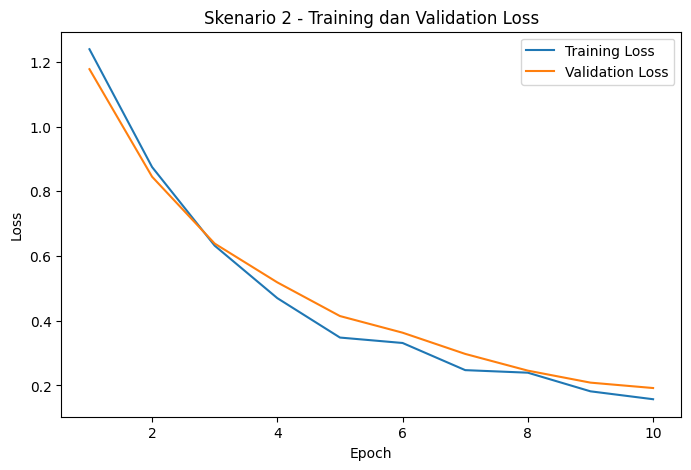

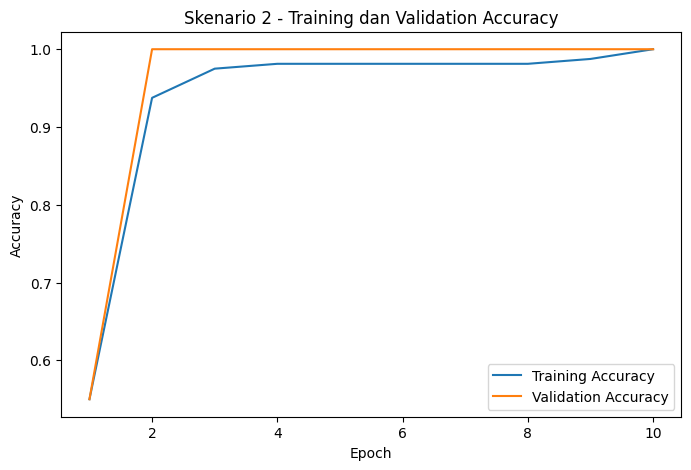

In [34]:
train_losses_s2, val_losses_s2, train_acc_s2, val_acc_s2 = history_s2

epochs_range_s2 = range(
    1,
    EPOCHS_S2 + 1
)

# Plot Loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range_s2,
    train_losses_s2,
    label="Training Loss"
)

plt.plot(
    epochs_range_s2,
    val_losses_s2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Skenario 2 - Training dan Validation Loss"
)

plt.legend()
plt.show()


# Plot Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range_s2,
    train_acc_s2,
    label="Training Accuracy"
)

plt.plot(
    epochs_range_s2,
    val_acc_s2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Skenario 2 - Training dan Validation Accuracy"
)

plt.legend()
plt.show()

In [35]:
model_s2.eval()

all_labels_s2 = []
all_predictions_s2 = []

with torch.no_grad():

    for images, labels in test_loader_s2:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_s2(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        all_labels_s2.extend(
            labels.cpu().numpy()
        )

        all_predictions_s2.extend(
            predicted.cpu().numpy()
        )

print("Testing Skenario 2 selesai.")
print(
    "Jumlah data test:",
    len(all_labels_s2)
)

Testing Skenario 2 selesai.
Jumlah data test: 20


In [36]:
accuracy_s2 = accuracy_score(
    all_labels_s2,
    all_predictions_s2
)

precision_s2 = precision_score(
    all_labels_s2,
    all_predictions_s2,
    average="macro",
    zero_division=0
)

recall_s2 = recall_score(
    all_labels_s2,
    all_predictions_s2,
    average="macro",
    zero_division=0
)

f1_s2 = f1_score(
    all_labels_s2,
    all_predictions_s2,
    average="macro",
    zero_division=0
)

print("HASIL EVALUASI SKENARIO 2")
print("==========================")
print(f"Accuracy  : {accuracy_s2:.4f}")
print(f"Precision : {precision_s2:.4f}")
print(f"Recall    : {recall_s2:.4f}")
print(f"F1-Score  : {f1_s2:.4f}")

HASIL EVALUASI SKENARIO 2
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


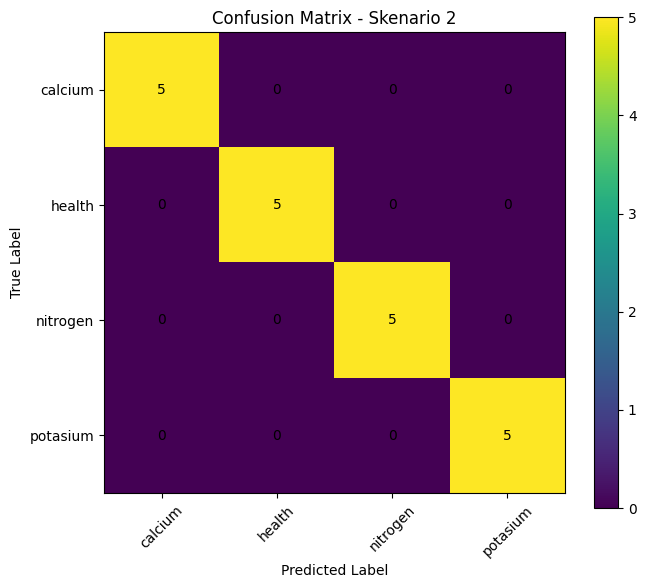

In [37]:
cm_s2 = confusion_matrix(
    all_labels_s2,
    all_predictions_s2
)

plt.figure(figsize=(7, 6))

plt.imshow(cm_s2)

plt.title(
    "Confusion Matrix - Skenario 2"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(train_dataset_s2.classes)),
    train_dataset_s2.classes,
    rotation=45
)

plt.yticks(
    range(len(train_dataset_s2.classes)),
    train_dataset_s2.classes
)

for i in range(cm_s2.shape[0]):
    for j in range(cm_s2.shape[1]):

        plt.text(
            j,
            i,
            cm_s2[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [38]:
report_s2 = classification_report(
    all_labels_s2,
    all_predictions_s2,
    target_names=train_dataset_s2.classes,
    zero_division=0
)

print("CLASSIFICATION REPORT - SKENARIO 2")
print("===================================")
print(report_s2)

CLASSIFICATION REPORT - SKENARIO 2
              precision    recall  f1-score   support

     calcium       1.00      1.00      1.00         5
      health       1.00      1.00      1.00         5
    nitrogen       1.00      1.00      1.00         5
    potasium       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



**SKENARIO 3**

In [39]:
train_dataset_s3 = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform_aug
)

val_dataset_s3 = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset_s3 = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

print("Dataset Skenario 3 berhasil dibuat.")

print("\nJumlah data:")
print("Train      :", len(train_dataset_s3))
print("Validation :", len(val_dataset_s3))
print("Test       :", len(test_dataset_s3))

print("\nNama kelas:")
print(train_dataset_s3.classes)

Dataset Skenario 3 berhasil dibuat.

Jumlah data:
Train      : 160
Validation : 20
Test       : 20

Nama kelas:
['calcium', 'health', 'nitrogen', 'potasium']


In [40]:
train_loader_s3 = DataLoader(
    train_dataset_s3,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader_s3 = DataLoader(
    val_dataset_s3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader_s3 = DataLoader(
    test_dataset_s3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoader Skenario 3 berhasil dibuat.")
print("Batch size:", BATCH_SIZE)

DataLoader Skenario 3 berhasil dibuat.
Batch size: 16


In [41]:
model_s3 = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Freezing all layers initially
for param in model_s3.parameters():
    param.requires_grad = False

# Unfreeze the last convolutional block (layer4) and the fully connected layer
for param in model_s3.layer4.parameters():
    param.requires_grad = True

num_classes = len(train_dataset_s3.classes)
num_features = model_s3.fc.in_features

model_s3.fc = nn.Linear(
    num_features,
    num_classes
)

# Ensure the new fc layer is trainable
for param in model_s3.fc.parameters():
    param.requires_grad = True

model_s3 = model_s3.to(device)

print("Model Skenario 3 berhasil dibuat dengan fine-tuning.")
print("Jumlah kelas:", num_classes)
print("Kelas:", train_dataset_s3.classes)

Model Skenario 3 berhasil dibuat dengan fine-tuning.
Jumlah kelas: 4
Kelas: ['calcium', 'health', 'nitrogen', 'potasium']


In [42]:
criterion_s3 = nn.CrossEntropyLoss()

# Optimizer includes parameters from the unfrozen layer4 and the new fc layer
optimizer_s3 = torch.optim.Adam([
    {'params': model_s3.fc.parameters()},
    {'params': model_s3.layer4.parameters(), 'lr': 0.0001} # Lower learning rate for fine-tuning
], lr=0.001)

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam (fine-tuning layer4 with smaller LR)")
print("Learning rate : 0.001 (for fc) and 0.0001 (for layer4)")

Loss function : CrossEntropyLoss
Optimizer     : Adam (fine-tuning layer4 with smaller LR)
Learning rate : 0.001 (for fc) and 0.0001 (for layer4)


In [43]:
EPOCHS_S3 = 10 # You can adjust the number of epochs

history_s3 = train_model(
    model=model_s3,
    train_loader=train_loader_s3,
    val_loader=val_loader_s3,
    criterion=criterion_s3,
    optimizer=optimizer_s3,
    epochs=EPOCHS_S3
)

Epoch [1/10] Train Loss: 1.0748 | Train Acc: 0.7750 | Val Loss: 0.8005 | Val Acc: 0.7500
Epoch [2/10] Train Loss: 0.3909 | Train Acc: 0.9437 | Val Loss: 0.1264 | Val Acc: 0.9500
Epoch [3/10] Train Loss: 0.0560 | Train Acc: 1.0000 | Val Loss: 0.0157 | Val Acc: 1.0000
Epoch [4/10] Train Loss: 0.0543 | Train Acc: 0.9875 | Val Loss: 0.0034 | Val Acc: 1.0000
Epoch [5/10] Train Loss: 0.0130 | Train Acc: 1.0000 | Val Loss: 0.0008 | Val Acc: 1.0000
Epoch [6/10] Train Loss: 0.0287 | Train Acc: 0.9938 | Val Loss: 0.0006 | Val Acc: 1.0000
Epoch [7/10] Train Loss: 0.0065 | Train Acc: 1.0000 | Val Loss: 0.0008 | Val Acc: 1.0000
Epoch [8/10] Train Loss: 0.0059 | Train Acc: 1.0000 | Val Loss: 0.0007 | Val Acc: 1.0000
Epoch [9/10] Train Loss: 0.0053 | Train Acc: 1.0000 | Val Loss: 0.0008 | Val Acc: 1.0000
Epoch [10/10] Train Loss: 0.0057 | Train Acc: 1.0000 | Val Loss: 0.0004 | Val Acc: 1.0000


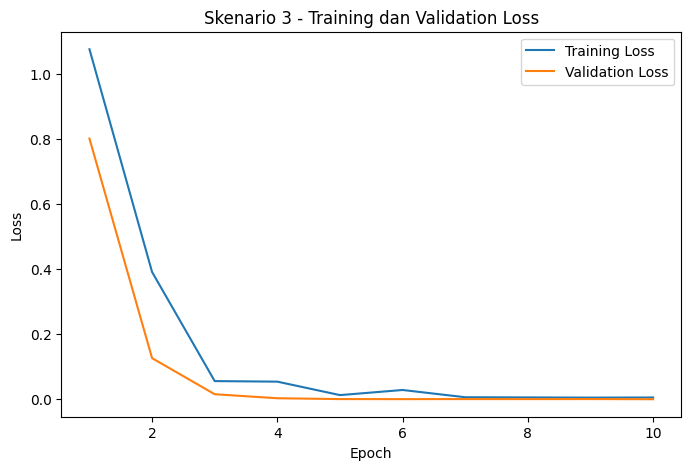

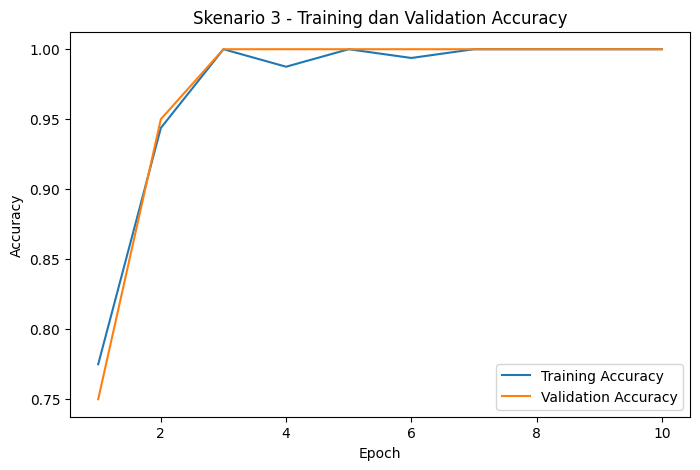

In [44]:
train_losses_s3, val_losses_s3, train_acc_s3, val_acc_s3 = history_s3

epochs_range_s3 = range(
    1,
    EPOCHS_S3 + 1
)

# Plot Loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range_s3,
    train_losses_s3,
    label="Training Loss"
)

plt.plot(
    epochs_range_s3,
    val_losses_s3,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Skenario 3 - Training dan Validation Loss"
)

plt.legend()
plt.show()


# Plot Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range_s3,
    train_acc_s3,
    label="Training Accuracy"
)

plt.plot(
    epochs_range_s3,
    val_acc_s3,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Skenario 3 - Training dan Validation Accuracy"
)

plt.legend()
plt.show()

In [45]:
model_s3.eval()

all_labels_s3 = []
all_predictions_s3 = []

with torch.no_grad():

    for images, labels in test_loader_s3:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_s3(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        all_labels_s3.extend(
            labels.cpu().numpy()
        )

        all_predictions_s3.extend(
            predicted.cpu().numpy()
        )

print("Testing Skenario 3 selesai.")
print(
    "Jumlah data test:",
    len(all_labels_s3)
)

Testing Skenario 3 selesai.
Jumlah data test: 20


In [46]:
accuracy_s3 = accuracy_score(
    all_labels_s3,
    all_predictions_s3
)

precision_s3 = precision_score(
    all_labels_s3,
    all_predictions_s3,
    average="macro",
    zero_division=0
)

recall_s3 = recall_score(
    all_labels_s3,
    all_predictions_s3,
    average="macro",
    zero_division=0
)

f1_s3 = f1_score(
    all_labels_s3,
    all_predictions_s3,
    average="macro",
    zero_division=0
)

print("HASIL EVALUASI SKENARIO 3")
print("==========================")
print(f"Accuracy  : {accuracy_s3:.4f}")
print(f"Precision : {precision_s3:.4f}")
print(f"Recall    : {recall_s3:.4f}")
print(f"F1-Score  : {f1_s3:.4f}")

HASIL EVALUASI SKENARIO 3
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


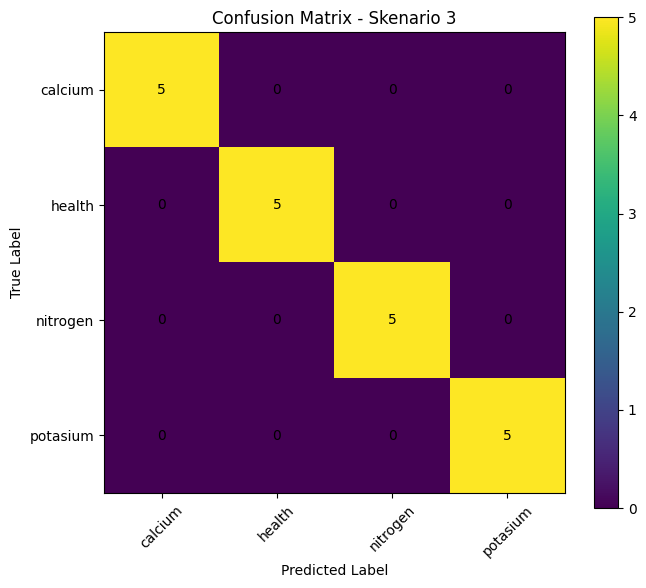

In [47]:
cm_s3 = confusion_matrix(
    all_labels_s3,
    all_predictions_s3
)

plt.figure(figsize=(7, 6))

plt.imshow(cm_s3)

plt.title(
    "Confusion Matrix - Skenario 3"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(train_dataset_s3.classes)),
    train_dataset_s3.classes,
    rotation=45
)

plt.yticks(
    range(len(train_dataset_s3.classes)),
    train_dataset_s3.classes
)

for i in range(cm_s3.shape[0]):
    for j in range(cm_s3.shape[1]):

        plt.text(
            j,
            i,
            cm_s3[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

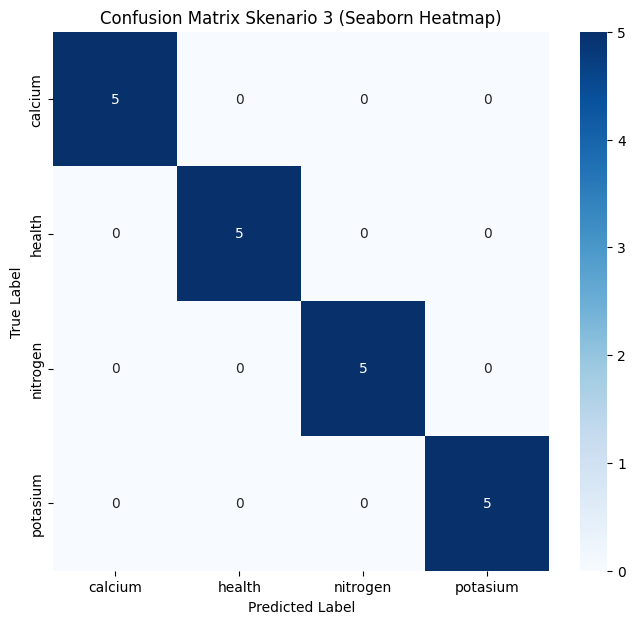

In [49]:
import seaborn as sns

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_s3,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset_s3.classes,
    yticklabels=train_dataset_s3.classes
)

plt.title("Confusion Matrix Skenario 3 (Seaborn Heatmap)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [50]:
report_s3 = classification_report(
    all_labels_s3,
    all_predictions_s3,
    target_names=train_dataset_s3.classes,
    zero_division=0
)

print("CLASSIFICATION REPORT - SKENARIO 3")
print("===================================")
print(report_s3)

CLASSIFICATION REPORT - SKENARIO 3
              precision    recall  f1-score   support

     calcium       1.00      1.00      1.00         5
      health       1.00      1.00      1.00         5
    nitrogen       1.00      1.00      1.00         5
    potasium       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

